# EDA - Breast Cancer

## Objetivo
Realizar un análisis exploratorio inicial del dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


## 1. Carga del dataset


In [3]:
df = pd.read_csv('/content/breast_cancer.csv')
print('Shape:', df.shape)
print('Columnas:', df.columns.tolist())
display(df.head())
display(df.tail())
df.info()


Shape: (569, 32)
Columnas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target', 'target_name']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,malignant
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1,benign


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 2. Estadísticas descriptivas


In [4]:
display(df.describe().T)

numericas = df.select_dtypes(include=['int64','float64']).columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

print('Variables numéricas:', numericas)
print('Variables categóricas:', categoricas)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Variables numéricas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']
Variables categóricas: ['target_name']


## 3. Distribución de variables categóricas


In [5]:
for col in categoricas:
    print('\n', col)
    display(df[col].value_counts(dropna=False))



 target_name


,count
target_name,
benign,357
malignant,212


## 4. Valores nulos y duplicados


In [6]:
print('Valores nulos por columna:')
display(df.isnull().sum())

duplicados = df.duplicated().sum()
print('Filas duplicadas:', duplicados)
print('Porcentaje:', round(duplicados / len(df) * 100, 2), '%')


Valores nulos por columna:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


Filas duplicadas: 0
Porcentaje: 0.0 %


## 5. Histogramas


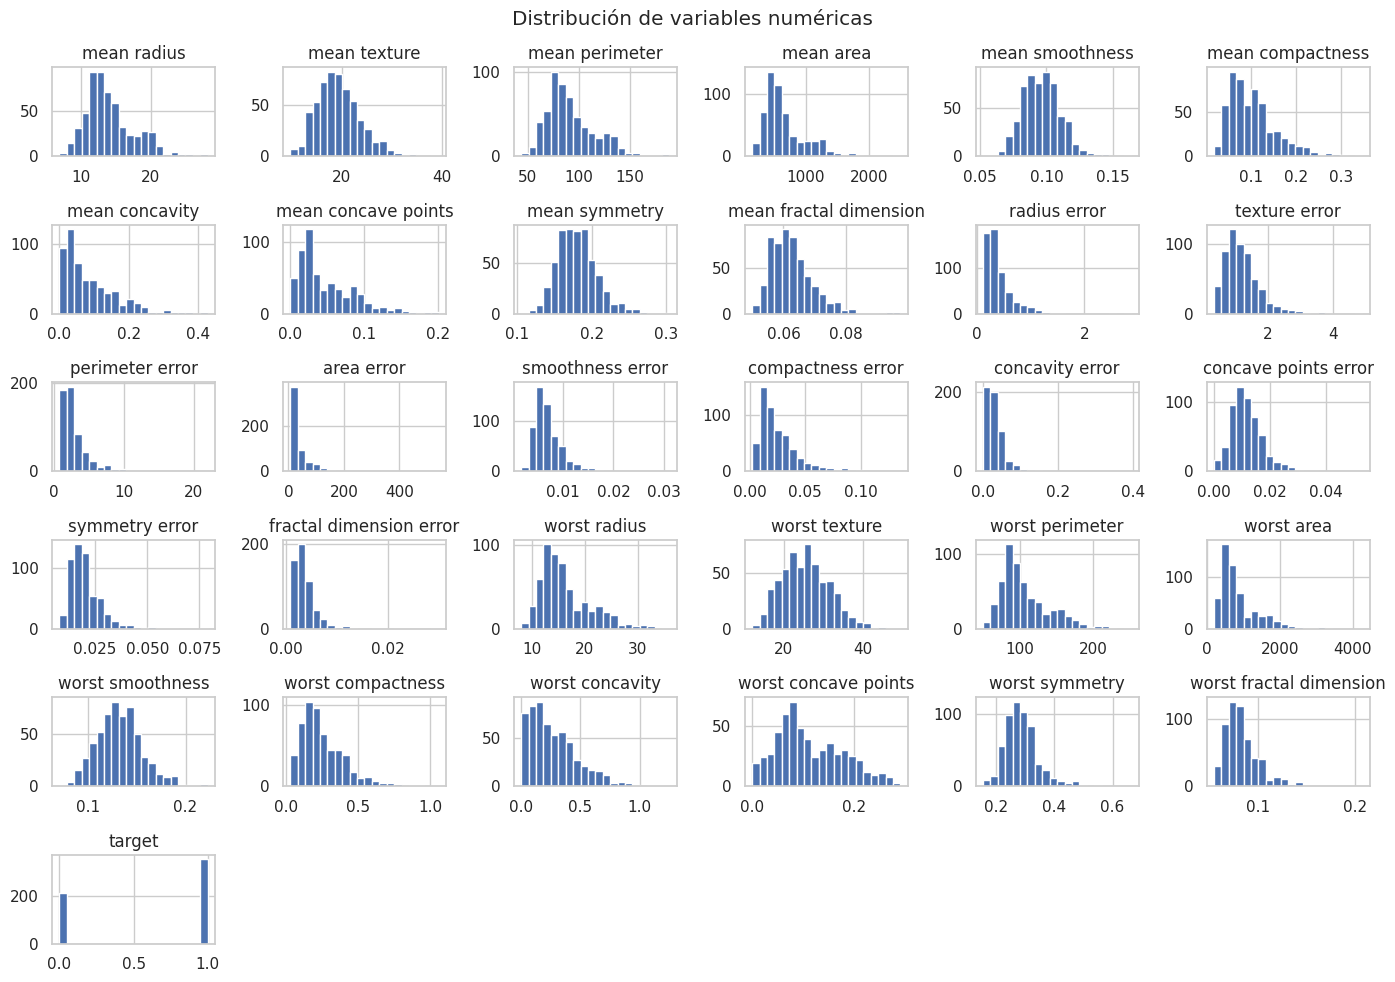

In [7]:
df[numericas].hist(figsize=(14,10), bins=20)
plt.suptitle('Distribución de variables numéricas')
plt.tight_layout()
plt.show()


## 6. Gráficos de barras


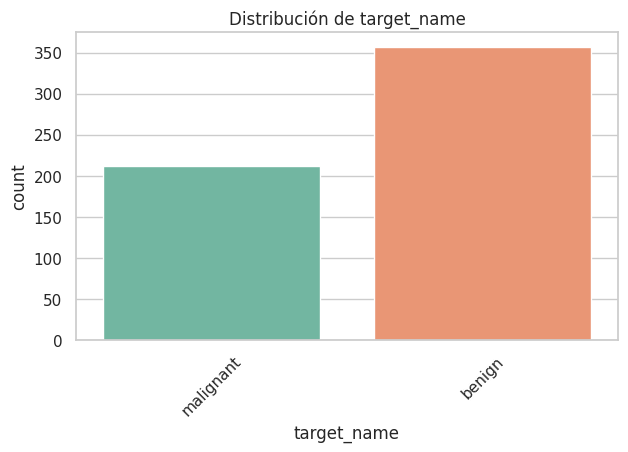

In [8]:
if len(categoricas) > 0:
    for col in categoricas:
        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
        plt.title('Distribución de ' + col)
        plt.xticks(rotation=45)
        plt.show()
else:
    print('No hay variables categóricas de tipo object.')


## 7. Boxplots e identificación de outliers


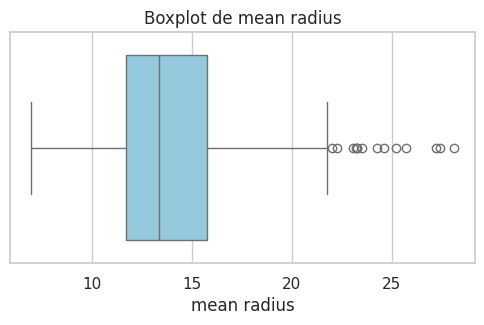

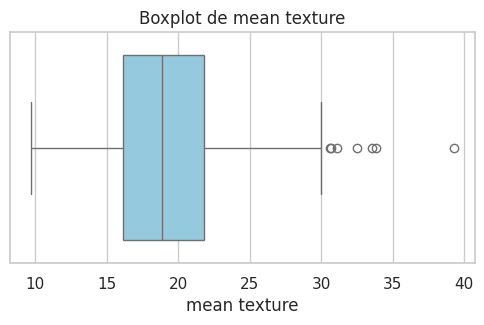

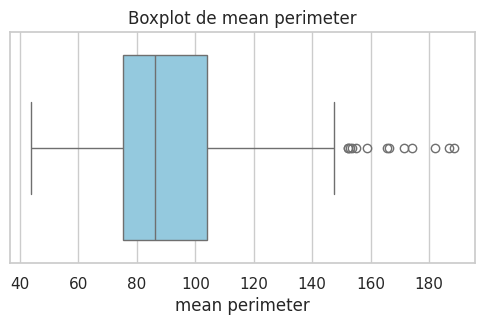

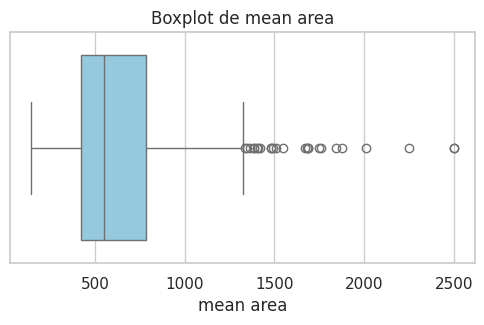

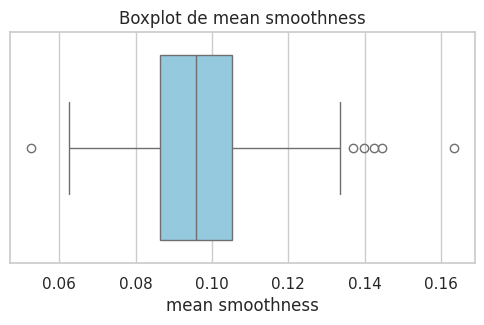

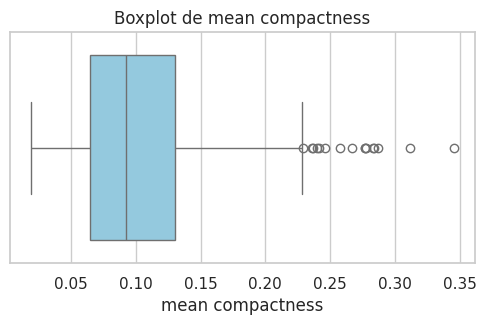

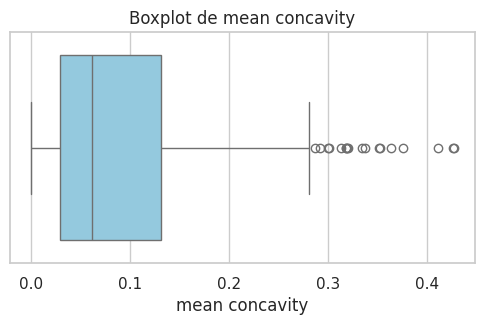

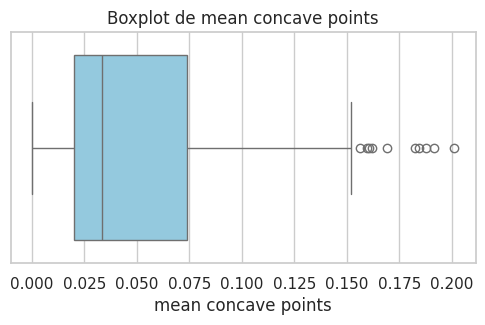

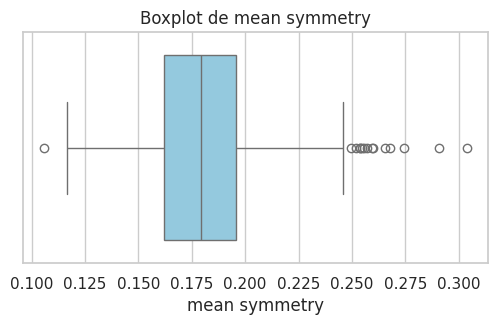

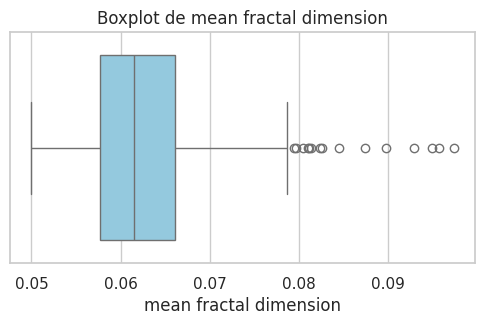

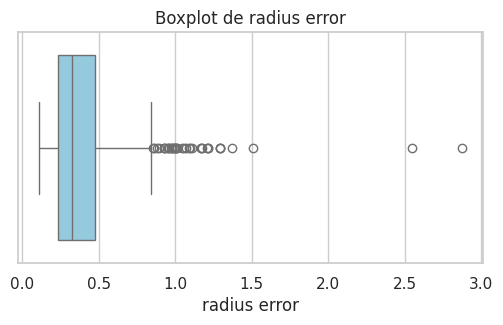

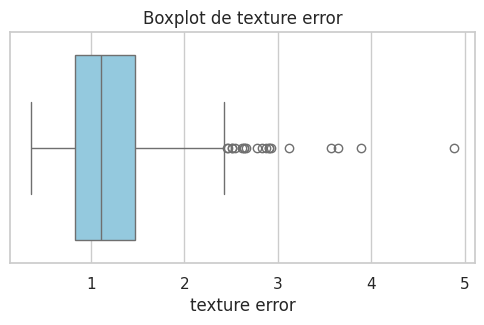

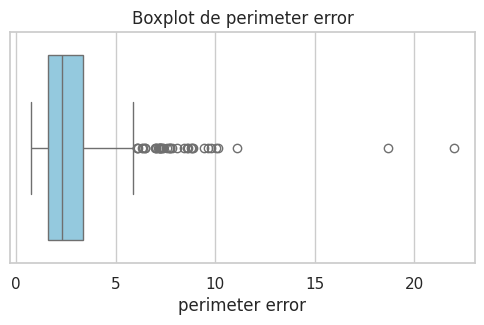

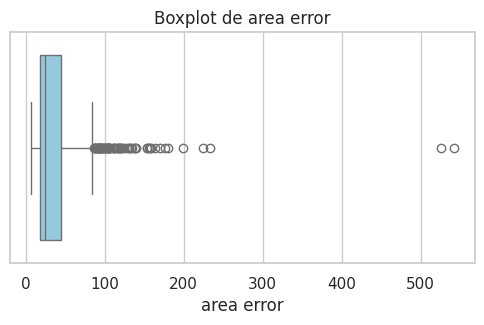

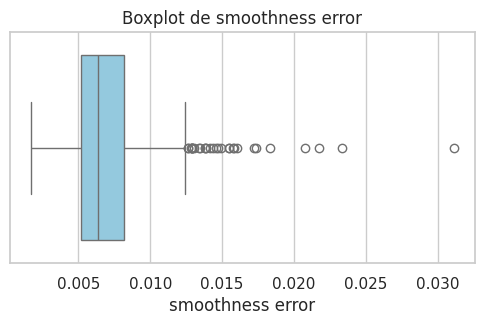

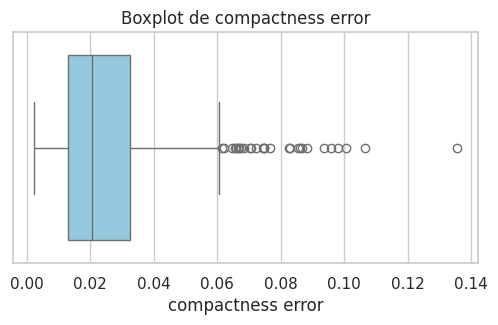

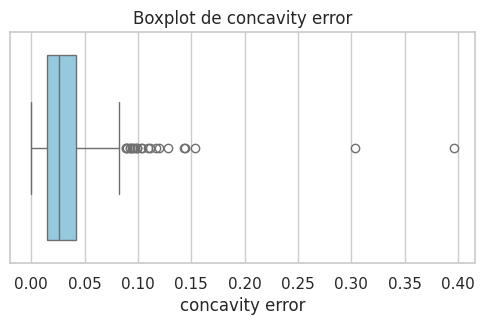

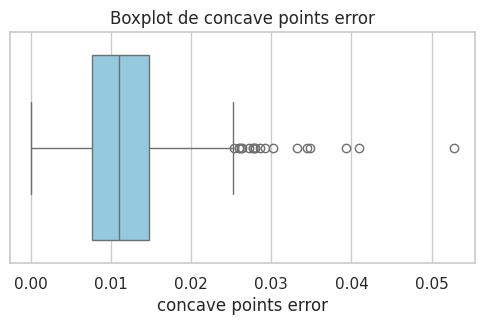

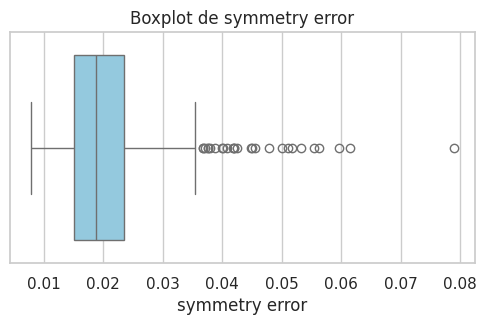

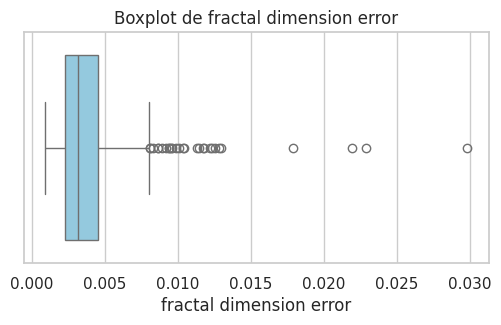

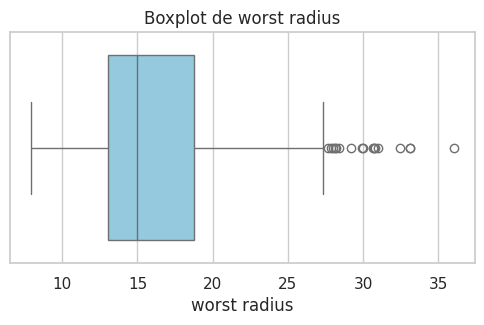

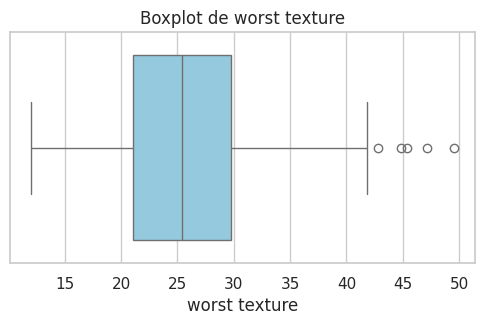

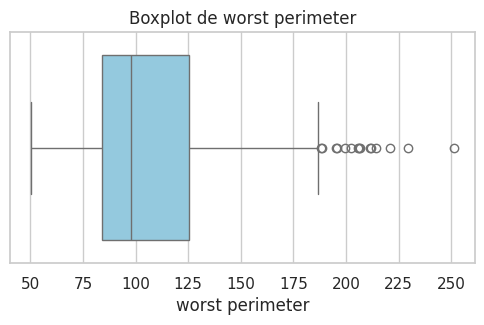

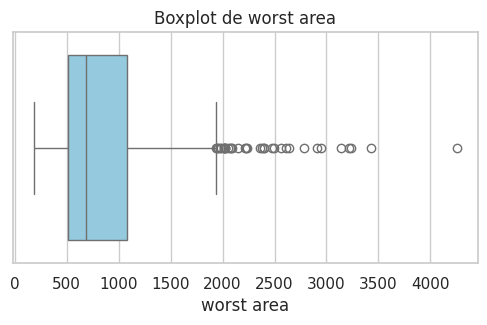

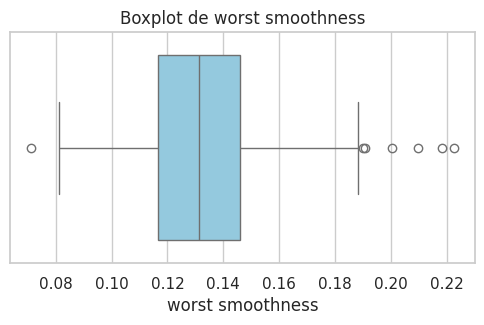

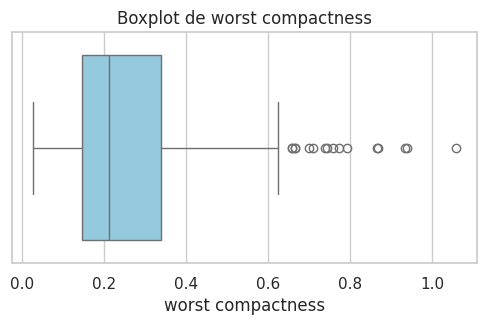

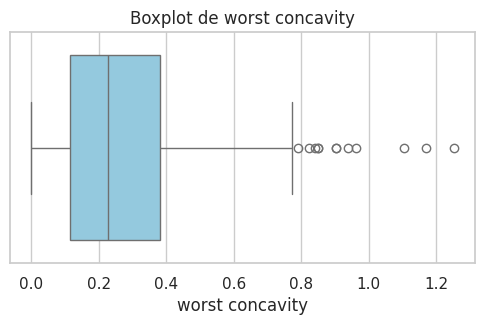

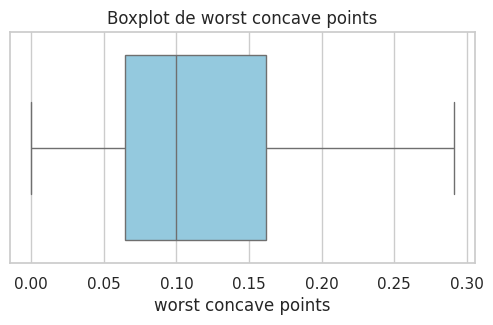

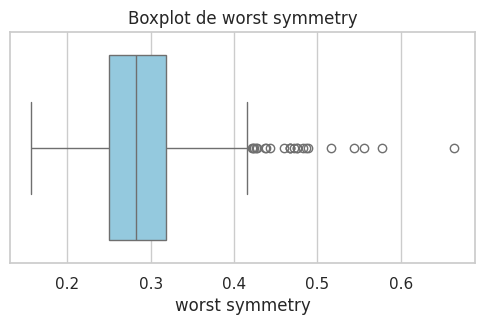

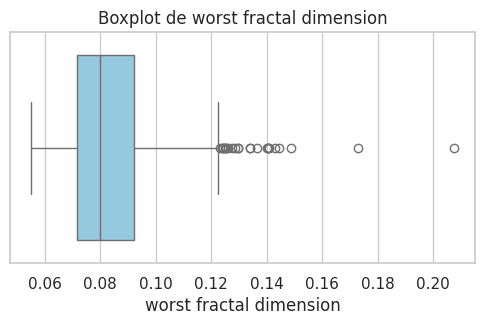

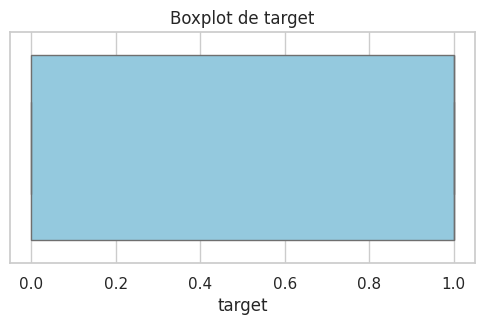

mean radius : 14 outliers
mean texture : 7 outliers
mean perimeter : 13 outliers
mean area : 25 outliers
mean smoothness : 6 outliers
mean compactness : 16 outliers
mean concavity : 18 outliers
mean concave points : 10 outliers
mean symmetry : 15 outliers
mean fractal dimension : 15 outliers
radius error : 38 outliers
texture error : 20 outliers
perimeter error : 38 outliers
area error : 65 outliers
smoothness error : 30 outliers
compactness error : 28 outliers
concavity error : 22 outliers
concave points error : 19 outliers
symmetry error : 27 outliers
fractal dimension error : 28 outliers
worst radius : 17 outliers
worst texture : 5 outliers
worst perimeter : 15 outliers
worst area : 35 outliers
worst smoothness : 7 outliers
worst compactness : 16 outliers
worst concavity : 12 outliers
worst concave points : 0 outliers
worst symmetry : 23 outliers
worst fractal dimension : 24 outliers
target : 0 outliers


In [9]:
for col in numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title('Boxplot de ' + col)
    plt.show()

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR
    cantidad = ((df[col] < inferior) | (df[col] > superior)).sum()
    print(col, ':', cantidad, 'outliers')


## 8. Mapa de calor de correlación


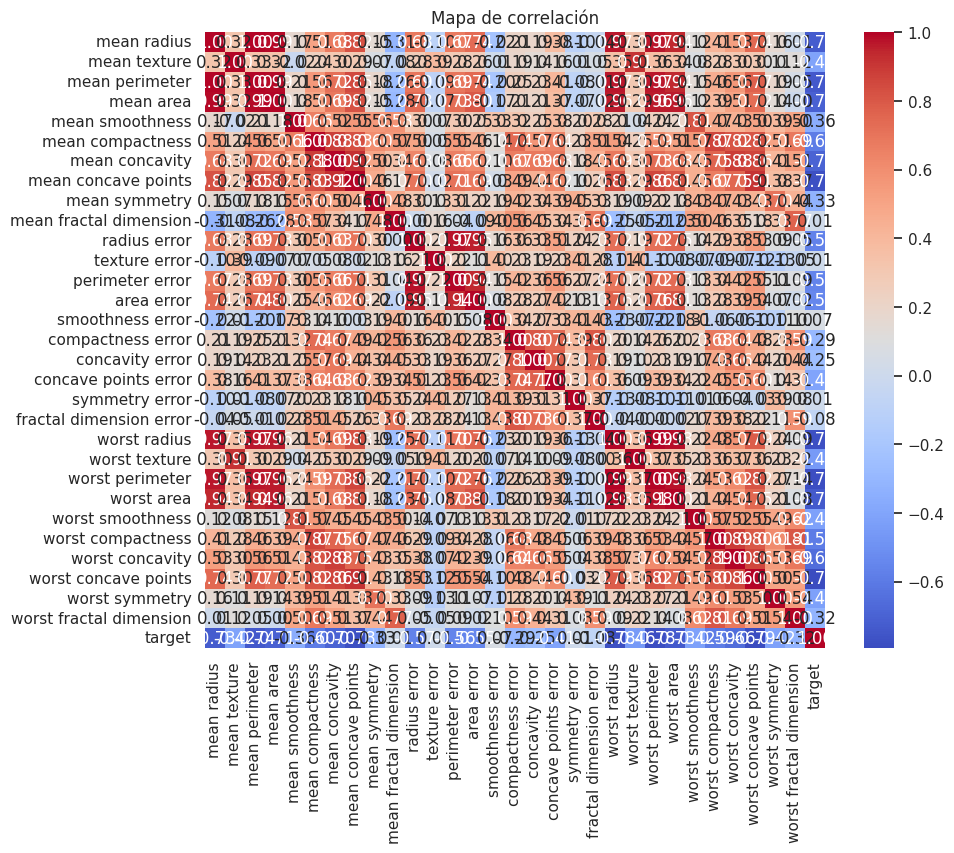

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de correlación')
plt.show()


## 9. Diagnóstico inicial

**Tipo de problema sugerido:** Clasificación binaria.

**Variable objetivo sugerida:** `target`.

**Resumen:** Dataset adecuado para practicar EDA, preprocesamiento y modelado inicial.
